# Video Game Research Project: Planning Stage

## 1. Data Description

In [1]:
library(tidyverse)
library(lubridate)
library(dplyr)
options(repr.matrix.max.rows = 6)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


### Dataset summary  
Data generated by research group in Computer Science at UBC, led by Frank Wood.  
Game research project goal is to enable advanced AI research by analyzing player's actions on a MineCraft(PLAICraft) server.
Data collected from the people who signed up and played on PLAICraft server. 
#### Players dataset summary    
Contains a list of all unique players and data about each player.   
**Number of observations**: 196   
**Number of variables**: 7  
**Summary statistics**:
|                            |Average    |Min    |Max|
|----------------------------|-----------|-------|-------|
|**Total time played (in hours)**|5.85       |0      |223.10|
|**User's age**                 |21         |9      |58|    

**Variables**:  
- `experience`(character) - User's experience level. Five categories: Pro, Veteran, Amateur, Regular and Beginner.
- `subscribe`(logical) - User's subscription status to a game-related newsletter.
- `hashedEmail`(character) - Encoded user's email.
- `played_hours`(double) - Total hours played by user.
- `name`(character) - User's first name.
- `gender`(character) - User's gender. Seven categories: Male, Female, Non-binary, Prefer not to say, Agender, Two-Spirited, Other.
- `Age`(integer) - User's age.  
**Potential issues**:
  - inconsistent column names
  - missing age values
  - factor values stored as charcters
  - played hours precision (stored as hours not minutes)  
### Sessions dataset summary
Contains a list of individual play sessions by each player and data about the session.  
**Number of observations**: 1535   
**Number of variables**: 5  
**Observation period**: 06/04/2024 - 26/09/2024   
**Variables**:  
- `hashedEmail`(character) - Encoded user's email.
- `start_time`(character) - Formatted date and time of the player`s game session start.
- `end_time`(character) - Formatted date and time of the player`s game session end.
- `original_start_time`(double) - Date and time of the player`s game session start stored as a number.
- `original_end_time`(double) - Date and time of the player`s game session end stored as a number.  
**Potential issues**:
  - inconsistent column names
  - missing time values
  - start_time and end_time stored as character values, not in a dattime format

#### Computation of players dataset summary

In [2]:
url_players <- "https://raw.githubusercontent.com/ALagodzinska/project_planning_stage/refs/heads/main/data/players.csv"

players <- read_delim(url_players, delim = ",")
# Converted categorical variables into factors for summary
players <- players |> mutate(experience = as_factor(experience), gender = as_factor(gender))
players

summary(players)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<fct>,<lgl>,<chr>,<dbl>,<chr>,<fct>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


    experience subscribe       hashedEmail         played_hours    
 Pro     :14   Mode :logical   Length:196         Min.   :  0.000  
 Veteran :48   FALSE:52        Class :character   1st Qu.:  0.000  
 Amateur :63   TRUE :144       Mode  :character   Median :  0.100  
 Regular :36                                      Mean   :  5.846  
 Beginner:35                                      3rd Qu.:  0.600  
                                                  Max.   :223.100  
                                                                   
     name                         gender         Age       
 Length:196         Male             :124   Min.   : 9.00  
 Class :character   Female           : 37   1st Qu.:17.00  
 Mode  :character   Non-binary       : 15   Median :19.00  
                    Prefer not to say: 11   Mean   :21.14  
                    Agender          :  2   3rd Qu.:22.75  
                    Two-Spirited     :  6   Max.   :58.00  
                    Other           

#### Computation of sessions dataset summary

In [3]:
url_sessions <- "https://raw.githubusercontent.com/ALagodzinska/project_planning_stage/refs/heads/main/data/sessions.csv"

sessions <- read_delim(url_sessions, delim = ",")
sessions

summary(sessions)

# Used for observation period summary
print("First record date")
data_start_date <- sessions |> slice_min(original_start_time, n = 1) |> 
    select(start_time) |> slice(1) |> pull() |> strsplit(" ")
data_start_date

print("Last record date")
data_end_date <- sessions |> slice_max(original_end_time, n = 1) |>
    select(end_time) |> slice(1) |> pull() |> strsplit(" ")
data_end_date

Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


hashedEmail,start_time,end_time,original_start_time,original_end_time
<chr>,<chr>,<chr>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12
⋮,⋮,⋮,⋮,⋮
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,28/07/2024 15:36,28/07/2024 15:57,1.72218e+12,1.72218e+12
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,25/07/2024 06:15,25/07/2024 06:22,1.72189e+12,1.72189e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,20/05/2024 02:26,20/05/2024 02:45,1.71617e+12,1.71617e+12


 hashedEmail         start_time          end_time         original_start_time
 Length:1535        Length:1535        Length:1535        Min.   :1.712e+12  
 Class :character   Class :character   Class :character   1st Qu.:1.716e+12  
 Mode  :character   Mode  :character   Mode  :character   Median :1.719e+12  
                                                          Mean   :1.719e+12  
                                                          3rd Qu.:1.722e+12  
                                                          Max.   :1.727e+12  
                                                                             
 original_end_time  
 Min.   :1.712e+12  
 1st Qu.:1.716e+12  
 Median :1.719e+12  
 Mean   :1.719e+12  
 3rd Qu.:1.722e+12  
 Max.   :1.727e+12  
 NA's   :2          

[1] "First record date"


[[1]]
[1] "06/04/2024" "09:35"

[1] "Last record date"


[[1]]
[1] "26/09/2024" "07:39"

## 2. Questions

### Broad question
- **Question 3:** What time windows are most likely to have large number of simultaneous players?

### Specific question
- Can the time of the day and the day of the week predict the number of active players in the sessions dataset?

The collected start and end time session data can help to identify times when the player was present. This data can be used to calculate the number of active players within each defined period.   
To be able to answer this question, we need to extract times and days of the week from the time columns, add new columns for these new values. Then group data by date, time period and the day of the week and add the column that will summarize the number of active players. Time period and day of the week might be be categorical values.

## 3. Exploratory Data Analysis and Visualization

### Loading data set into R

#### Loading players dataset into R

In [4]:
url_players <- "https://raw.githubusercontent.com/ALagodzinska/project_planning_stage/refs/heads/main/data/players.csv"

players <- read_delim(url_players, delim = ",")
players

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


#### Loading sessions dataset into R

In [5]:
url_sessions <- "https://raw.githubusercontent.com/ALagodzinska/project_planning_stage/refs/heads/main/data/sessions.csv"

sessions <- read_delim(url_sessions, delim = ",")
sessions

Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


hashedEmail,start_time,end_time,original_start_time,original_end_time
<chr>,<chr>,<chr>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12
⋮,⋮,⋮,⋮,⋮
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,28/07/2024 15:36,28/07/2024 15:57,1.72218e+12,1.72218e+12
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,25/07/2024 06:15,25/07/2024 06:22,1.72189e+12,1.72189e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,20/05/2024 02:26,20/05/2024 02:45,1.71617e+12,1.71617e+12


### Basic Data Wrangling

#### Players Dataset Wrangling

In [6]:
# Converting experience and gender columns from char to factor.
players_clean <- players |> mutate(experience = as_factor(experience), gender = as_factor(gender))

# Fill missing age values with mean age value.
mean_age <- players |>
    summarize(mean_age = mean(Age, na.rm = TRUE)) |>
    round() |>
    pull()

players_clean <- players_clean |> 
    mutate(Age = if_else(is.na(Age), mean_age, Age))

# Create consistent column names
players_clean <- players_clean |> rename(is_subscribed = subscribe, hashed_email = hashedEmail, age = Age)

players_clean

experience,is_subscribed,hashed_email,played_hours,name,gender,age
<fct>,<lgl>,<chr>,<dbl>,<chr>,<fct>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,21


#### Sessions Dataset Wrangling

In [7]:
# Separate date and time from start_time and end_time columns
start_column_names <- c("start_date", "start_time")
end_column_names <- c("end_date", "end_time")

sessions_clean <- sessions |> separate(start_time, start_column_names, " ") |>
    separate(end_time, end_column_names, " ")

# Convert time and date to date and period type by using lubridate.
sessions_clean <- sessions_clean |>
    mutate(start_date = dmy(start_date), end_date = dmy(end_date), 
            start_time = hm(start_time), end_time = hm(end_time))

# Remove missing values
sessions_clean <- sessions_clean |> drop_na() 

# Create consistent column names
sessions_clean <- sessions_clean |> rename(hashed_email = hashedEmail, start_timestamp = original_start_time, end_timestamp = original_end_time)

sessions_clean

hashed_email,start_date,start_time,end_date,end_time,start_timestamp,end_timestamp
<chr>,<date>,<Period>,<date>,<Period>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,2024-06-30,18H 12M 0S,2024-06-30,18H 24M 0S,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,2024-06-17,23H 33M 0S,2024-06-17,23H 46M 0S,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,2024-07-25,17H 34M 0S,2024-07-25,17H 57M 0S,1.72193e+12,1.72193e+12
⋮,⋮,⋮,⋮,⋮,⋮,⋮
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,2024-07-28,15H 36M 0S,2024-07-28,15H 57M 0S,1.72218e+12,1.72218e+12
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,2024-07-25,6H 15M 0S,2024-07-25,6H 22M 0S,1.72189e+12,1.72189e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,2024-05-20,2H 26M 0S,2024-05-20,2H 45M 0S,1.71617e+12,1.71617e+12


### Mean values for each quantitative variable in the players data set

In [8]:
players_mean_values <- players_clean |>
    select(played_hours, age) |>    
    map_df(mean) |>
    mutate(played_hours = round(played_hours, 2), age = round(age)) |>
    rename("Average total play time in hours" = played_hours, "Average player's age" = age)

players_mean_values

Average total play time in hours,Average player's age
<dbl>,<dbl>
5.85,21


### Exploratory visualizations


#### Change in the number of active players daily between 06/04/2024 and 26/09/2024.

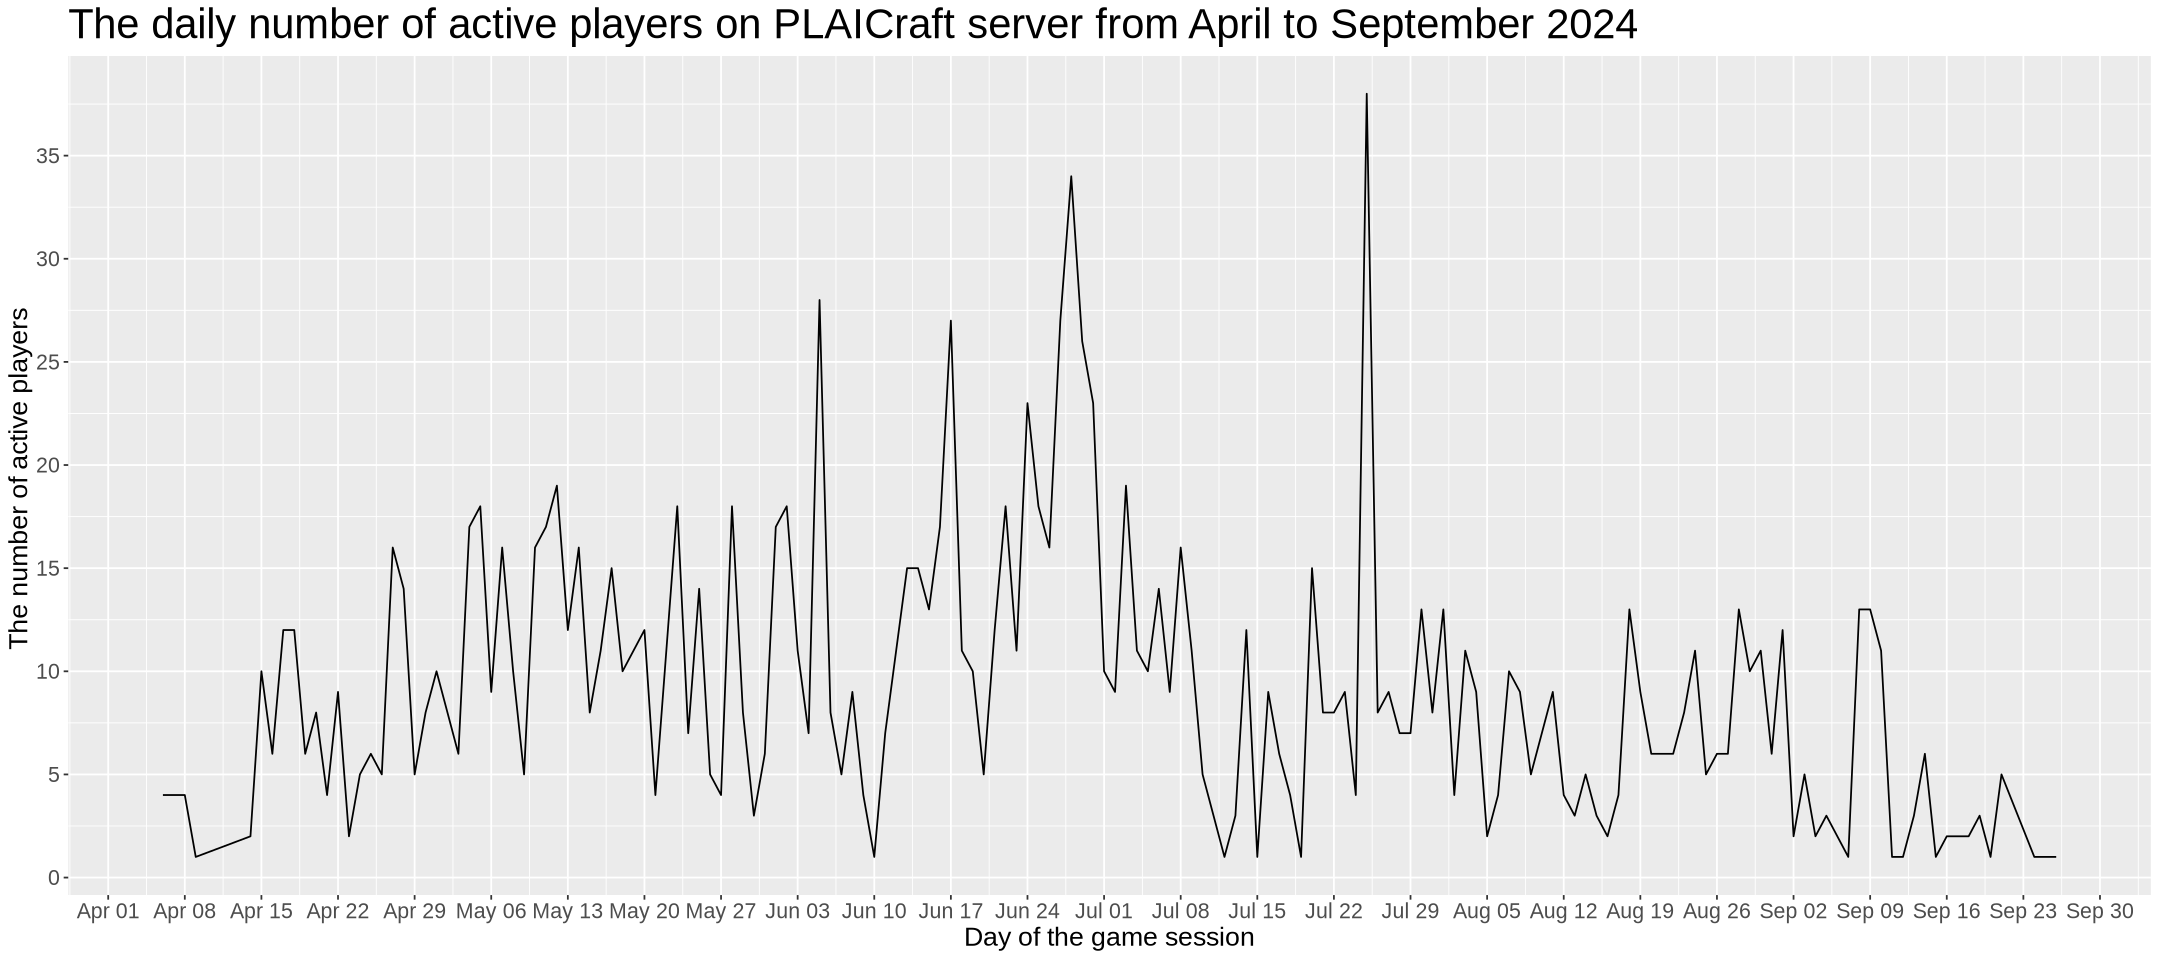

In [9]:
active_players_by_date <- sessions_clean |> 
     group_by(start_date) |>
     summarize(active_players_count = n())

options(repr.plot.width = 18, repr.plot.height = 8) 

active_players_by_date_plot <- active_players_by_date |>
    ggplot(aes(x = start_date, y = active_players_count)) +
    geom_line() +
    scale_x_date(breaks = "1 week",date_labels = "%b %d") +
    scale_y_continuous(breaks = seq(0, 40, by = 5)) + 
    labs(x = "Day of the game session", y = "The number of active players ") +
    ggtitle("The daily number of active players on PLAICraft server from April to September 2024") +
    theme(text = element_text(size = 16), plot.title = element_text(size = 25))
    

active_players_by_date_plot

**Insights**:  
- The highest numbers of active players was during the summer months - June and July.
- The trend is fluctuating over time, with no specific pattern.

#### The monthly number of active players on PLAICraft server from April to September 2024

`summarise()` has grouped output by 'month'. You can override using the
`.groups` argument.


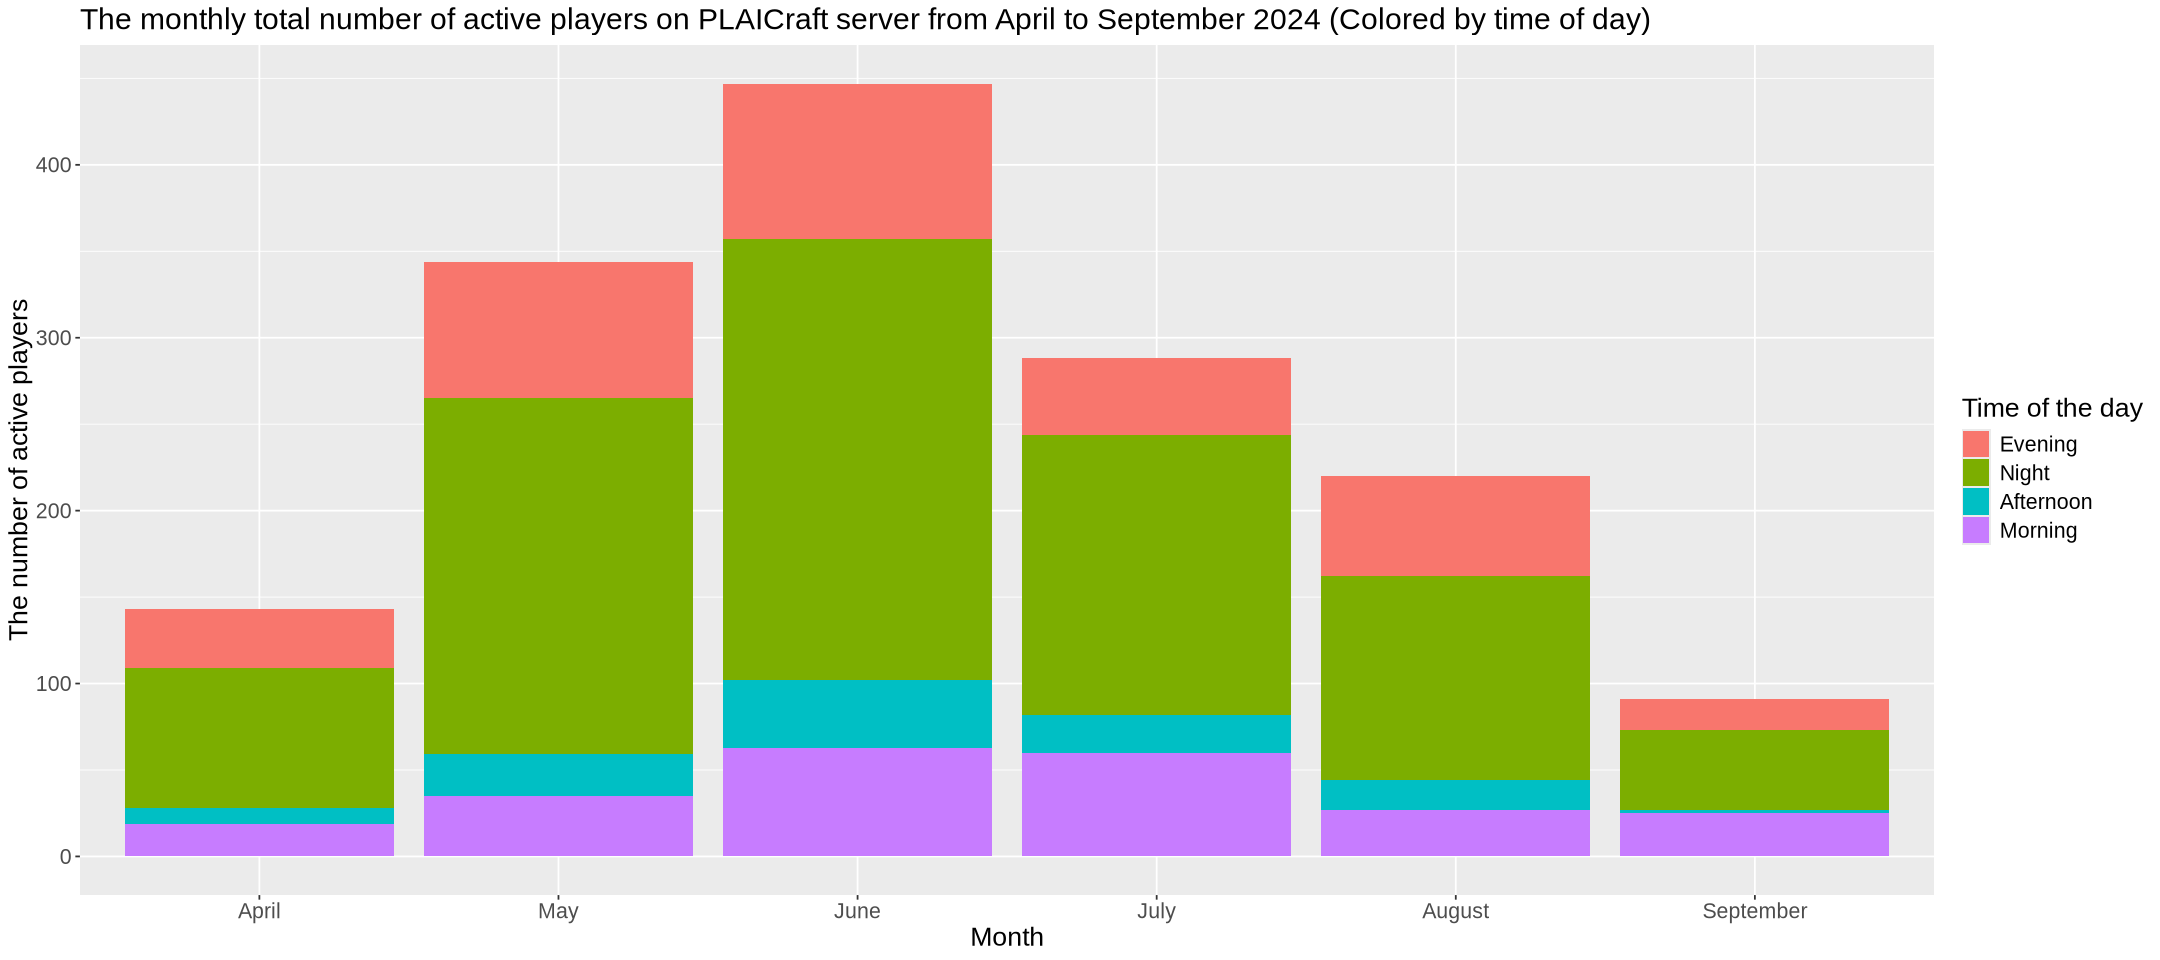

In [19]:
evening_start_time <- hm("18:00")
evening_end_time <- hm("22:00")

morning_start_time <- hm("06:00")
morning_end_time <- hm("12:00")

afternoon_start_time <- hm("12:00")
afternoon_end_time <- hm("18:00")

sessions_with_playtime_category <- sessions_clean |>
    mutate(time_of_day = 
        ifelse((start_time >= evening_start_time & start_time < evening_end_time) |  (end_time >=  evening_start_time & end_time < evening_end_time), "Evening",
        ifelse((start_time >= morning_start_time & start_time < morning_end_time) | (end_time >=  morning_start_time & end_time < morning_end_time), "Morning",
        ifelse((start_time >= afternoon_start_time & start_time < afternoon_end_time) | (end_time >=  afternoon_start_time & end_time < afternoon_end_time), "Afternoon",
        "Night")))) |>
    mutate(time_of_day = as_factor(time_of_day))
               

active_players_by_month_and_time <- sessions_with_playtime_category |> 
    group_by(month = month(start_date), time_of_day) |>
    summarize(active_players_count = n()) |>
    mutate(month = factor(month,
                           levels = c(4, 5, 6, 7, 8, 9),
                           labels = c("April", "May", "June", "July", "August", "September")))

options(repr.plot.width = 18, repr.plot.height = 8) 

active_players_by_month_and_time_plot <- active_players_by_month_and_time |>
    ggplot(aes(x = month, y = active_players_count, fill = time_of_day)) +
    geom_bar(stat = "identity") +
    labs(x = "Month", y = "The number of active players", fill = "Time of the day") +
    ggtitle("The monthly total number of active players on PLAICraft server from April to September 2024 (Colored by time of day)") +
    theme(text = element_text(size = 16), plot.title = element_text(size = 18))
    

active_players_by_month_and_time_plot

**Insights**:   
- The highest number of active players was in the month of June.
- The distribution of active players by the session time of the day remains similar from month to month.
- Most of the players play during the night time (from 22:00 until 06:00)

#### The number of active players on PLAICraft server by the day of the week from April to September 2024

`summarise()` has grouped output by 'day_of_week'. You can override using the
`.groups` argument.


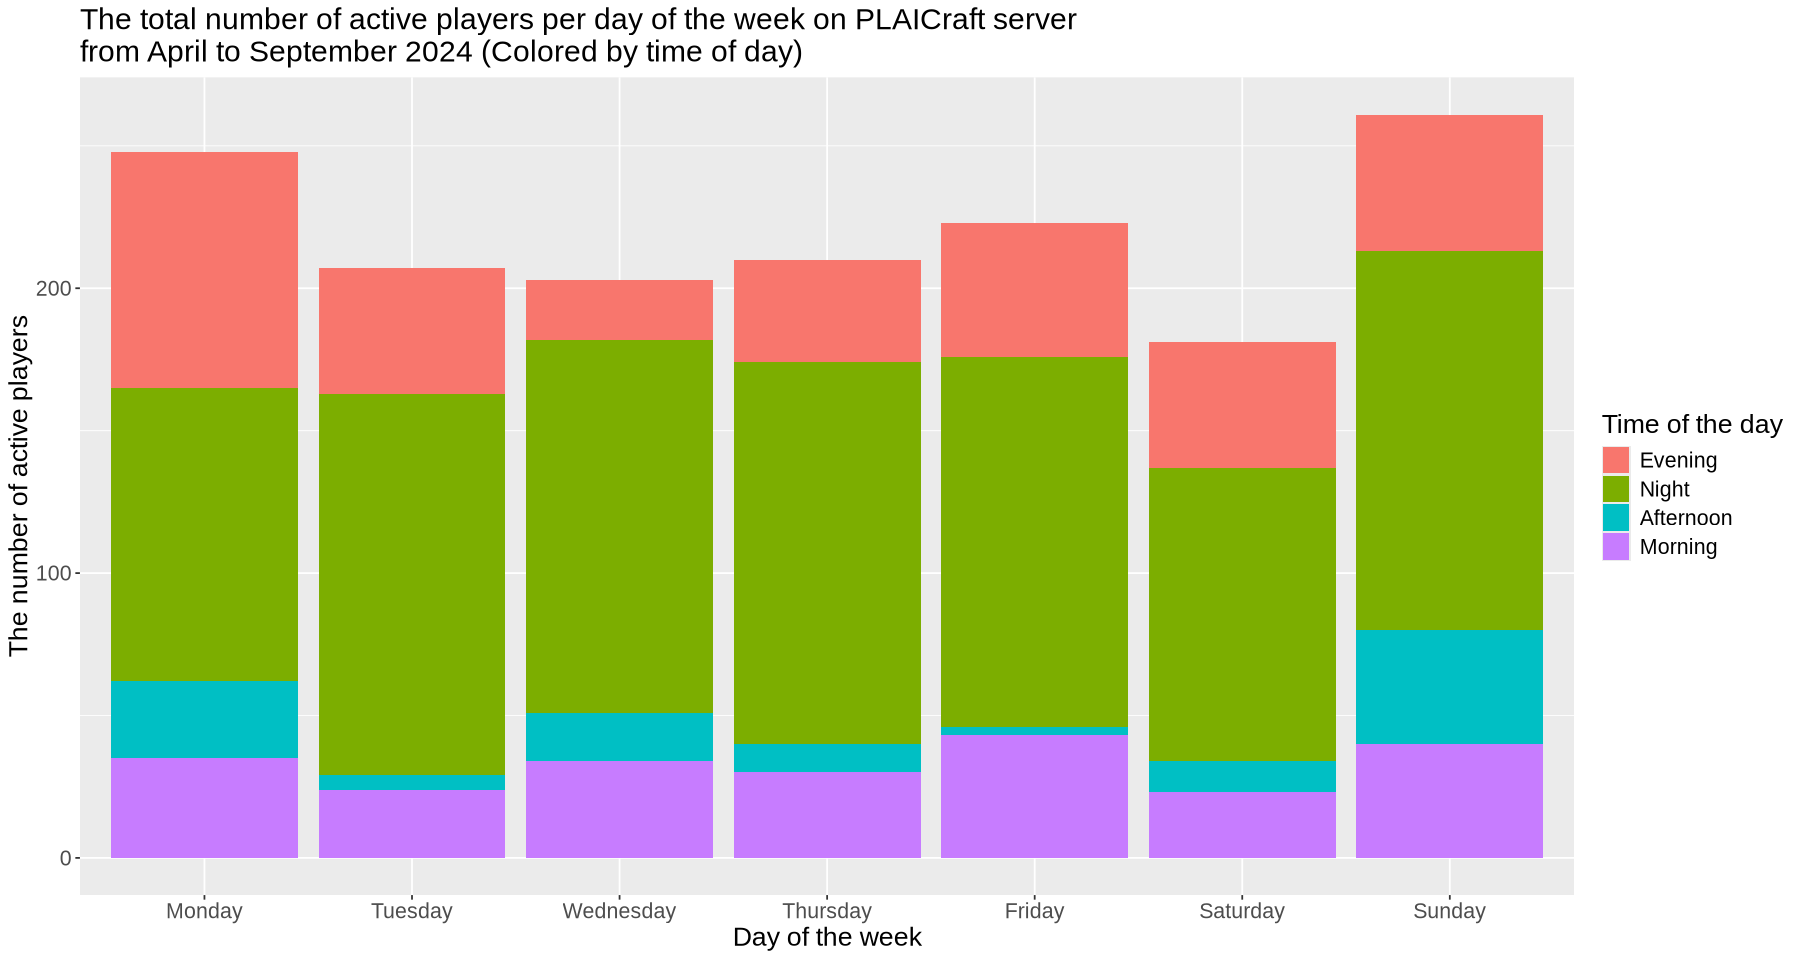

In [20]:
active_players_by_day_of_week <- sessions_with_playtime_category |> 
    group_by(day_of_week = wday(start_date), time_of_day)  |>
    summarize(active_players_count = n()) |>
    mutate(day_of_week = factor(day_of_week,
                           levels = c(1, 2, 3, 4, 5, 6, 7),
                           labels = c("Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday")))

options(repr.plot.width = 15, repr.plot.height = 8) 

active_players_by_day_of_week_plot <- active_players_by_day_of_week |>
    ggplot(aes(x = day_of_week, y = active_players_count, fill = time_of_day)) +
    geom_bar(stat = "identity") +
    labs(x = "Day of the week", y = "The number of active players", fill = "Time of the day") +
    ggtitle("The total number of active players per day of the week on PLAICraft server\nfrom April to September 2024 (Colored by time of day)") +
    theme(text = element_text(size = 16), plot.title = element_text(size = 18))
    
active_players_by_day_of_week_plot

**Insights**:  
- Total highest player's activity is on Sunday and Monday.
- Players in total are less active on Saturday, even though it is the weekend.
- Most of the players play during the night time (from 22:00 to 06:00) and very little play in the afternoon. (from 12:00 to 18:00)

#### Potential problems
- Prossibly number of active users should be counted by both start session date and end session date. Especially since a lot of players play during the night - when date changes.
- There is not a big difference in the number of active players in total by the day of the week. Therefore it might not have a big effect on predicting the number of active players.
- For deeper annalysis length of the session can be considered. As the very short session may not depict the number of active users during specified period.
- Maybe four time of the day periods is not enough to find a pattern, and shorter time periods should be considered.